In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random

from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.neighbors import kneighbors_graph

from torchvision.datasets import MNIST

from dataset_builder import *
from clustering_utils import *
from Siamese_networks import *

In [5]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

# MNIST: immagini (X) in [0, 255] e label (y)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = StandardScaler().fit_transform(X)

In [6]:
subset_indices = np.random.choice(len(X), 10000, replace=False)
X_sub = X[subset_indices]
y_sub = y[subset_indices]

pca = PCA(n_components=64)
X_pca = pca.fit_transform(X_sub)

gamma = 1e-3
W = rbf_kernel(X_pca, gamma=gamma) 

W_sparse = kneighbors_graph(X_pca, n_neighbors=10, mode='connectivity', include_self=True)

In [ ]:
sc = SpectralClustering(n_clusters=10, affinity='precomputed')
labels_pred = sc.fit_predict(W)

y_sub = y_sub.astype(int)

Applicando t-SNE per visualizzazione...


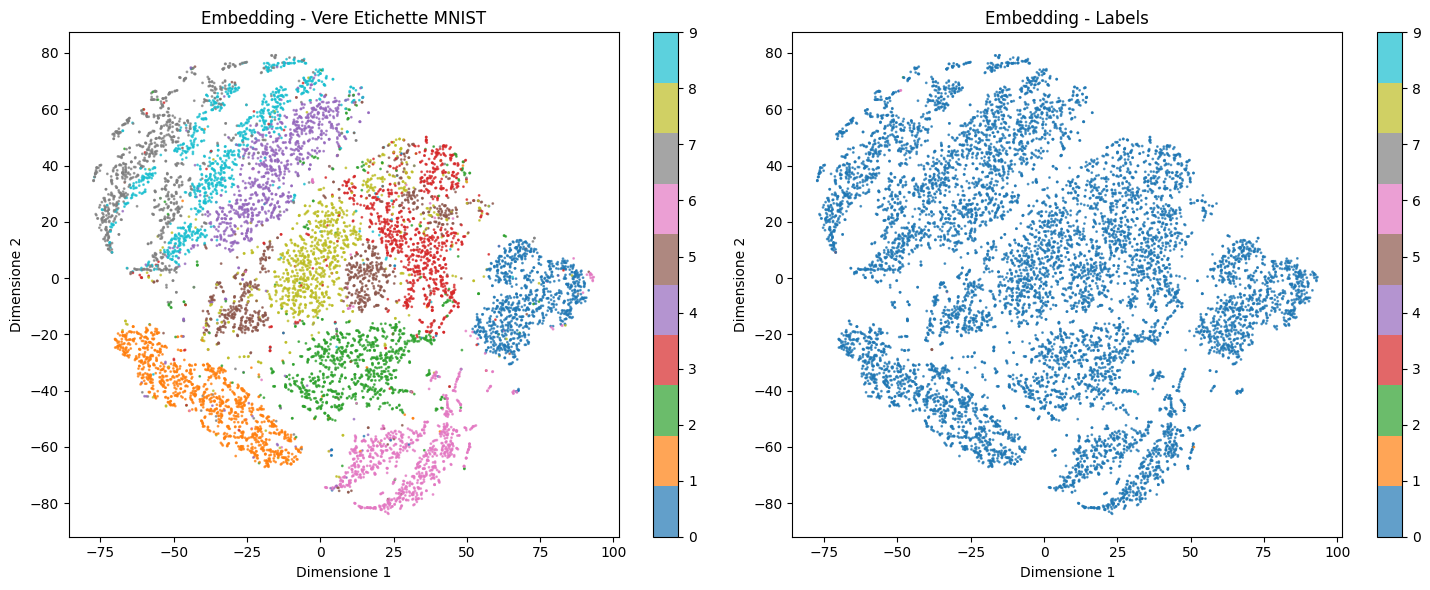

In [ ]:
visualize_embeddings(embeddings = X_sub, embedding_size=64, true_labels=y_sub, cluster_labels = labels_pred)

---

In [9]:
tsne = TSNE(n_components=3, random_state=0, perplexity=30, n_iter=1000) # n_components=64 non è tipico per t-SNE
X_tsne = tsne.fit_transform(X_sub)

gamma = 1e-3
W = rbf_kernel(X_pca, gamma=gamma) 

W_sparse = kneighbors_graph(X_pca, n_neighbors=10, mode='connectivity', include_self=True)

c:\Users\Lorenzo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [10]:
sc = SpectralClustering(n_clusters=10, affinity='precomputed')
labels_pred = sc.fit_predict(W)

y_sub = y_sub.astype(int)

Applicando t-SNE per visualizzazione...


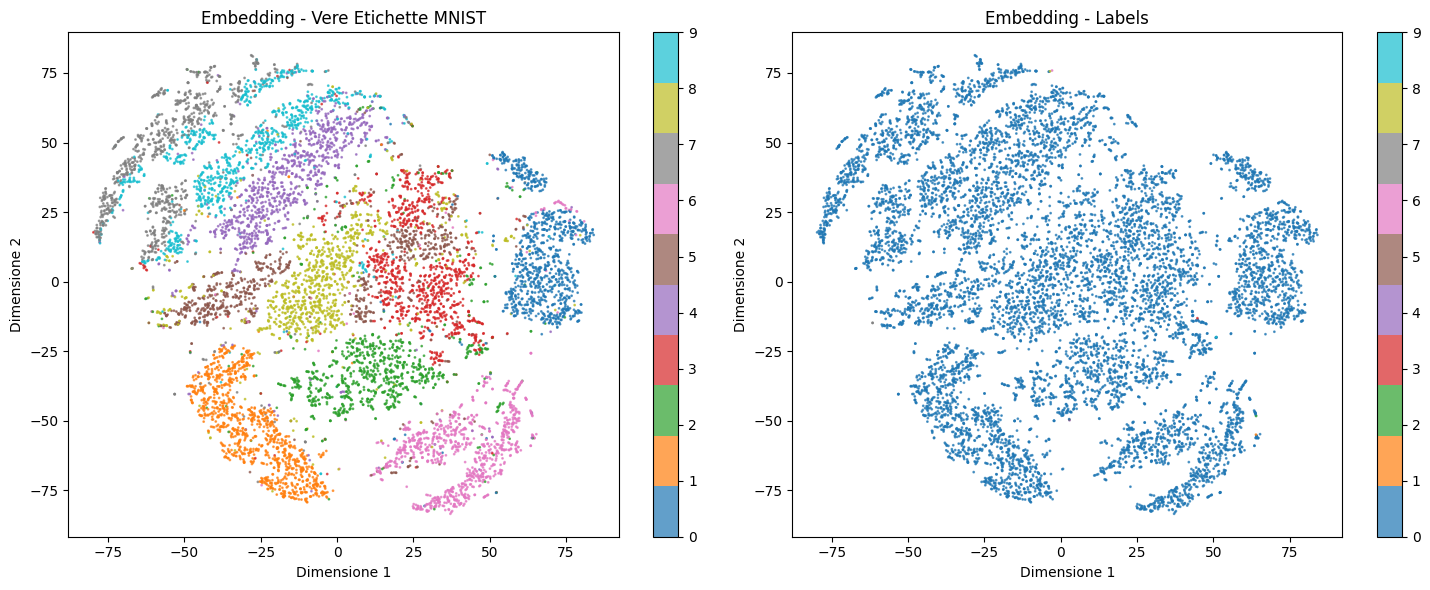

In [11]:
visualize_embeddings(embeddings = X_sub, embedding_size=64, true_labels=y_sub, cluster_labels = labels_pred)